# Investigate fraud with temporal graph exports

**Goal.** Build observable and oracle graph views, inspect a compact fraud-oriented query result, export Neo4j-compatible files, and optionally run a live Cypher smoke check.

**Prerequisites.** Base FraudTwin install. Optional extras and Docker commands are clearly marked.

**Produces.** A view comparison, relationship summaries, one diagnostic plot, and a dependency-free Neo4j export.


**Source size.** The graph fixture generates fewer than 1,000 payments and includes graph campaigns for observable/oracle comparison.

**Offline path.** All marked offline cells run without Docker or network services. Service cells are optional and explicitly marked in notebook metadata.

**Important.** Observable data is safe for detector inputs; oracle campaign membership is for investigation and evaluation only.


In [1]:
!pip install neo4j matplotlib


[notice] A new release of pip is available: 26.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


## Optional Neo4j setup
The first cell installs the Neo4j driver. Start Neo4j only for live Cypher checks; graph export and investigation remain offline.

```bash
docker run --name fraudtwin-neo4j --detach --rm --publish 7474:7474 --publish 7687:7687 --env NEO4J_AUTH=neo4j/password neo4j:5
```

Use `FRAUDTWIN_NEO4J_URI`, `FRAUDTWIN_NEO4J_USER`, and `FRAUDTWIN_NEO4J_PASSWORD` for other endpoints. Stop with `docker stop fraudtwin-neo4j`; unavailable Bolt connections use the offline fallback.


**Set up a deterministic source run**


In [2]:
import json
from pathlib import Path

import polars as pl

from fraudtwin.config import load_config
from fraudtwin.generation import generate

root = next(
    (p for p in (Path.cwd(), *Path.cwd().parents) if (p / "configs" / "minimal.yaml").exists()),
    Path.cwd(),
)
config = load_config(root / "configs" / "benchmarks" / "m11-graph-v2.yaml")
data = generate(config, write=False)
run_id = data.run_id
payments = pl.DataFrame([item.model_dump(mode="json") for item in data.behavior.payments])
print("Source run")
print(f"  run_id: {run_id}")
print(f"  payments: {len(payments):,}")
print(f"  payment events: {len(data.behavior.payment_events):,}")
print(f"  graph campaigns: {len(data.behavior.graph_campaigns):,}")

Source run
  run_id: RUN-d4fe1230e312957d
  payments: 757
  payment events: 2,642
  graph campaigns: 13


**Build observable and oracle views**

The observable view contains relationships available to a detector. The oracle view adds campaign membership and investigation-only truth. Keeping both views side by side makes that boundary explicit.


In [3]:
from fraudtwin.graph import build_graph, validate_graph

graph = build_graph(config, data.entities, data.behavior, data.manifest, view="observable")
oracle_graph = build_graph(
    config,
    data.entities,
    data.behavior,
    data.manifest,
    view="oracle",
    memberships=data.behavior.graph_memberships,
)
validate_graph(graph)
validate_graph(oracle_graph)
view_summary = pl.DataFrame(
    [
        {
            "view": name,
            "nodes": item.node_frame.height,
            "edges": item.edge_frame.height,
            "patterns": item.pattern_frame.height,
            "campaigns": item.campaign_frame.height,
            "memberships": item.membership_frame.height,
            "fingerprint": f"{item.output_fingerprint[:12]}...",
        }
        for name, item in (("observable", graph), ("oracle", oracle_graph))
    ]
)
display(view_summary)

view,nodes,edges,patterns,campaigns,memberships,fingerprint
str,i64,i64,i64,i64,i64,str
"""observable""",417,4191,899,0,0,"""db71520b71c0..."""
"""oracle""",443,4317,912,13,126,"""879b638b4400..."""


**Run compact graph queries offline**

This Polars query is the offline equivalent of a Cypher traversal from accounts to merchants. It lets the tutorial remain useful without requiring a running Neo4j server.


In [4]:
edge_counts = (
    graph.edge_frame.group_by("edge_type")
    .len()
    .rename({"len": "edges"})
    .sort("edges", descending=True)
)
top_accounts = (
    graph.edge_frame.filter(pl.col("edge_type") == "PAID")
    .group_by("src_id")
    .len()
    .rename({"src_id": "account_id", "len": "merchant_payments"})
    .sort("merchant_payments", descending=True)
)
print("Relationship types")
display(edge_counts.head(8))
print("Accounts with the most merchant payments")
display(top_accounts.head(8))

Relationship types


edge_type,edges
str,u32
"""USES""",960
"""SHARES_DEVICE""",680
"""TRANSFERRED_TO""",625
"""PAID""",526
"""PURCHASED_FROM""",526
"""RECEIVED_FROM""",488
"""OWNS""",240
"""HELD_AT""",120


Accounts with the most merchant payments


account_id,merchant_payments
str,u32
"""ACC-000078""",36
"""ACC-000117""",26
"""ACC-000092""",24
"""ACC-000077""",20
"""ACC-000088""",20
"""ACC-000057""",20
"""ACC-000075""",18
"""ACC-000114""",16


**Inspect detected graph patterns**

Patterns are observable structural findings. Campaign membership is intentionally absent from the observable view and remains available only in the oracle view.


In [5]:
pattern_summary = (
    graph.pattern_frame.group_by("pattern_type")
    .len()
    .rename({"len": "patterns"})
    .sort("patterns", descending=True)
)
print(f"Observable patterns: {graph.pattern_frame.height:,}")
display(pattern_summary.head(8))

Observable patterns: 899


pattern_type,patterns
str,u32
"""SHARED_DEVICE_INFRASTRUCTURE""",680
"""CYCLIC_RING""",165
"""MULE_NETWORK""",49
"""SHARED_IP_INFRASTRUCTURE""",3
"""FAN_IN""",1
"""FAN_OUT""",1


**Plot a local graph neighborhood**

The table above answers an aggregate question. This figure shows a readable two-hop neighborhood: the focus account, its direct neighbors, and neighbors-of-neighbors.


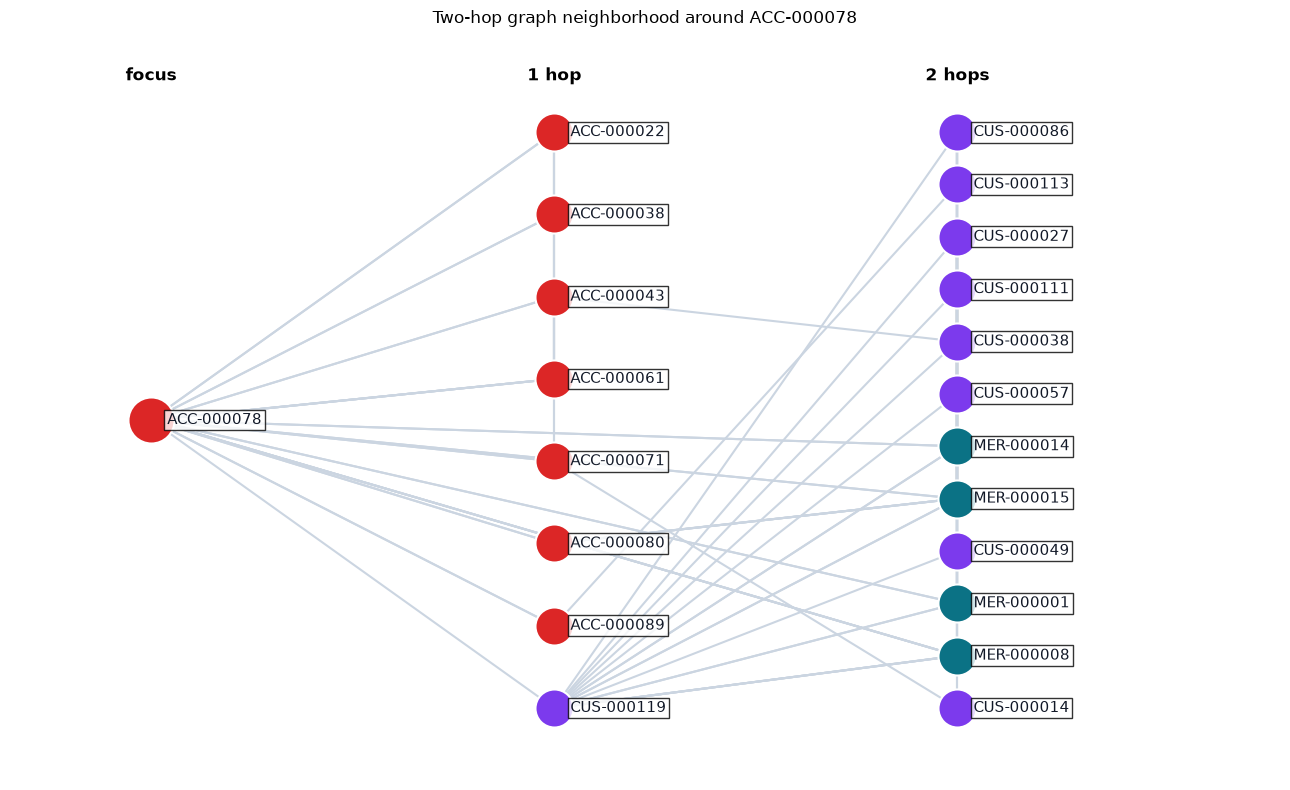

account_id,merchant_payments
str,u32
"""ACC-000078""",36
"""ACC-000117""",26
"""ACC-000092""",24
"""ACC-000077""",20
"""ACC-000088""",20
"""ACC-000057""",20
"""ACC-000075""",18
"""ACC-000114""",16


In [6]:
try:
    import matplotlib.pyplot as plt

    focus_id = top_accounts["account_id"][0]
    all_edges = graph.edge_frame.select(["src_id", "dst_id", "edge_type"]).to_dicts()
    adjacency = {}
    for edge in all_edges:
        adjacency.setdefault(edge["src_id"], set()).add(edge["dst_id"])
        adjacency.setdefault(edge["dst_id"], set()).add(edge["src_id"])
    first_hop = sorted(adjacency.get(focus_id, ()))[:8]
    second_candidates = {
        node_id
        for first_node in first_hop
        for node_id in adjacency.get(first_node, ())
        if node_id != focus_id and node_id not in first_hop
    }
    second_hop = sorted(
        second_candidates, key=lambda node_id: (-len(adjacency.get(node_id, ())), node_id)
    )[:12]
    visible_nodes = {focus_id, *first_hop, *second_hop}
    visible_edges = [
        edge
        for edge in all_edges
        if edge["src_id"] in visible_nodes and edge["dst_id"] in visible_nodes
    ]
    positions = {focus_id: (0.0, 0.0)}
    for y_value, node_id in enumerate(first_hop):
        positions[node_id] = (1.0, 1.0 - 2.0 * y_value / max(1, len(first_hop) - 1))
    for y_value, node_id in enumerate(second_hop):
        positions[node_id] = (2.0, 1.0 - 2.0 * y_value / max(1, len(second_hop) - 1))
    node_types = {row["node_id"]: row["node_type"] for row in graph.node_frame.to_dicts()}
    colors = {"ACCOUNT": "#dc2626", "MERCHANT": "#0b7285", "CUSTOMER": "#7c3aed"}
    fig, axis = plt.subplots(figsize=(13, 8))
    for edge in visible_edges:
        if edge["src_id"] in positions and edge["dst_id"] in positions:
            x_values = [positions[edge["src_id"]][0], positions[edge["dst_id"]][0]]
            y_values = [positions[edge["src_id"]][1], positions[edge["dst_id"]][1]]
            axis.plot(x_values, y_values, color="#cbd5e1", linewidth=1.5, zorder=1)
    for node_id, (x_value, y_value) in positions.items():
        node_type = node_types.get(node_id, "ENTITY")
        axis.scatter(
            [x_value],
            [y_value],
            s=1100 if node_id == focus_id else 750,
            color=colors.get(node_type, "#64748b"),
            edgecolor="white",
            linewidth=1.5,
            zorder=2,
        )
        axis.text(
            x_value + 0.04,
            y_value,
            node_id,
            ha="left",
            va="center",
            fontsize=11,
            color="#111827",
            bbox={"facecolor": "white", "alpha": 0.8, "pad": 2},
            zorder=3,
        )
    axis.text(0.0, 1.18, "focus", ha="center", fontsize=12, fontweight="bold")
    axis.text(1.0, 1.18, "1 hop", ha="center", fontsize=12, fontweight="bold")
    axis.text(2.0, 1.18, "2 hops", ha="center", fontsize=12, fontweight="bold")
    axis.set(
        title=f"Two-hop graph neighborhood around {focus_id}", xlim=(-0.35, 2.8), ylim=(-1.25, 1.35)
    )
    axis.axis("off")
    fig.tight_layout()
    plt.show()
    plt.close(fig)
except ImportError:
    print("Install matplotlib to render the two-hop graph neighborhood plot.")

display(top_accounts.head(8))

**Export dependency-free Neo4j artifacts**

The export contains CSV files, constraints, and import instructions. The temporary directory keeps this tutorial reproducible without leaving generated data in the repository.


In [7]:
from tempfile import TemporaryDirectory

from fraudtwin.graph import write_graph

with TemporaryDirectory(prefix="fraudtwin-neo4j-") as temp_dir:
    graph_dir, export_manifest = write_graph(
        {"observable": graph, "oracle": oracle_graph},
        Path(temp_dir) / "graphs",
        source_manifest=data.manifest,
        config=config,
        formats=("parquet", "neo4j"),
    )
    neo4j_dir = graph_dir / "observable" / "neo4j"
    export_files = pl.DataFrame(
        [{"file": path.name, "bytes": path.stat().st_size} for path in sorted(neo4j_dir.iterdir())]
    )
    neo4j_export_fingerprint = export_manifest.output_fingerprint

print("Neo4j-compatible export")
print("  views: observable, oracle")
print(f"  export fingerprint: {neo4j_export_fingerprint[:12]}...")
display(export_files)

Neo4j-compatible export
  views: observable, oracle
  export fingerprint: 5a93d4db744c...


file,bytes
str,i64
"""IMPORT.md""",611
"""constraints.cypher""",754
"""neo4j-admin-import.args""",52
"""nodes.csv""",32952
"""relationships.csv""",660311


**Verify the export and source rows**

The next cells keep the inspection readable and verify that the exported graph remains tied to the generated run.


In [8]:
# A compact inspection is more useful than printing an entire run.
sample_columns = [
    c for c in ("payment_id", "amount", "initiated_at", "payer_account_id") if c in payments.columns
]
sample_rows = payments.select(sample_columns).head(8).to_dicts()
print(f"Sample payments ({len(sample_rows)} of {payments.height} rows):")
for row in sample_rows:
    print(
        f"  - {row.get('payment_id')}: amount={row.get('amount')}, "
        f"initiated_at={row.get('initiated_at')}, payer={row.get('payer_account_id')}"
    )
nulls = {name: count for name, count in payments.null_count().to_dicts()[0].items() if count}
print("\nData quality summary:")
print(f"  rows: {payments.height}")
print(f"  columns: {payments.width}")
if not nulls:
    print("  nulls: none")
else:
    print("  columns with nulls:")
    for name, count in sorted(nulls.items()):
        print(f"    - {name}: {count}")

Sample payments (8 of 757 rows):
  - PAY-00000001: amount=16.48, initiated_at=2026-01-03T22:42:00Z, payer=ACC-000028
  - PAY-00000002: amount=50.72, initiated_at=2026-01-02T21:42:00Z, payer=ACC-000104
  - PAY-00000003: amount=10.0, initiated_at=2026-01-01T13:14:00Z, payer=ACC-000055
  - PAY-00000004: amount=393.98, initiated_at=2026-01-06T14:22:00Z, payer=ACC-000088
  - PAY-00000005: amount=14.33, initiated_at=2026-01-05T13:22:00Z, payer=ACC-000042
  - PAY-00000006: amount=10.0, initiated_at=2026-01-05T18:51:00Z, payer=ACC-000055
  - PAY-00000007: amount=19.03, initiated_at=2026-01-07T18:14:00Z, payer=ACC-000099
  - PAY-00000008: amount=20.44, initiated_at=2026-01-05T12:47:00Z, payer=ACC-000080

Data quality summary:
  rows: 757
  columns: 15
  columns with nulls:
    - card_id: 500
    - merchant_id: 488
    - payee_account_id: 12
    - payee_pix_key_id: 620
    - payer_pix_key_id: 620


**Review the run manifest**


In [9]:
summary = {
    "run_id": run_id,
    "payments": len(data.behavior.payments),
    "payment_events": len(data.behavior.payment_events),
    "fraud_records": len(data.behavior.fraud_records),
    "observable_patterns": graph.pattern_frame.height,
    "oracle_campaigns": oracle_graph.campaign_frame.height,
    "oracle_memberships": oracle_graph.membership_frame.height,
}
assert summary["payments"] == len(payments)
assert summary["payments"] > 0
print(json.dumps(summary, indent=2, default=str))

{
  "run_id": "RUN-d4fe1230e312957d",
  "payments": 757,
  "payment_events": 2642,
  "fraud_records": 57,
  "observable_patterns": 899,
  "oracle_campaigns": 13,
  "oracle_memberships": 126
}


**Run the optional live Neo4j smoke check**

This cell checks connectivity and a tiny write. It does not pretend that the temporary CSV export has already been imported into the server.


In [10]:
import os

try:
    from neo4j import GraphDatabase

    driver = GraphDatabase.driver(
        os.getenv("FRAUDTWIN_NEO4J_URI", "bolt://localhost:7687"),
        auth=(
            os.getenv("FRAUDTWIN_NEO4J_USER", "neo4j"),
            os.getenv("FRAUDTWIN_NEO4J_PASSWORD", "password"),
        ),
        connection_timeout=3.0,
    )
    driver.verify_connectivity()
    with driver.session() as session:
        ok = session.run("RETURN 1 AS ok").single()["ok"]
        loaded = session.run(
            "MERGE (n:FraudTwinTutorial {id: $id}) RETURN count(n) AS count",
            id=run_id,
        ).single()["count"]
    print({"connected": True, "query": ok, "tutorial_nodes": loaded})
except Exception as exc:
    print({"connected": False, "offline_fallback": True, "reason": type(exc).__name__})
finally:
    if "driver" in locals():
        driver.close()

{'connected': False, 'offline_fallback': True, 'reason': 'ServiceUnavailable'}


## Record the generated shape and tutorial contract


In [11]:
assert graph.output_fingerprint
assert oracle_graph.output_fingerprint
assert neo4j_export_fingerprint
assert oracle_graph.campaign_frame.height > 0
print("Verified: observable and oracle views are distinct and exportable.")

Verified: observable and oracle views are distinct and exportable.


In [12]:
assert graph.output_fingerprint
print({"offline_fallback": True, "graph_fingerprint": f"{graph.output_fingerprint}"})

{'offline_fallback': True, 'graph_fingerprint': 'db71520b71c00732be5357a67a93a9a643a141afc5ad214e3219bf761675f5f7'}
